# 💳 Credit Card Fraud Detection

## End-to-End Classification Project on Severely Imbalanced Data

### Workflow
1. Business Problem
2. Data Loading
3. Data Cleaning
4. Exploratory Data Analysis
5. Feature Engineering
6. Preprocessing — Encoding & Scaling
7. Model Building — Baseline Decision Tree
8. Handling Class Imbalance — Weighted Decision Tree
9. Model Evaluation & Comparison
10. Conclusion

## 1. Business Problem
Credit card fraud is rare (well under 1% of transactions here) but expensive. A classifier that flags suspicious transactions needs to catch as much fraud as possible (**recall**) without drowning analysts in false alarms (**precision**) — plain accuracy is misleading on data this imbalanced, so this notebook evaluates and compares models using precision, recall, F1, ROC-AUC and PR-AUC for the fraud class specifically.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## 2. Data Loading
Transaction-level data (simulated card-present/card-not-present transactions with cardholder and merchant metadata).

**Source:** [Credit Card Transactions Fraud Detection Dataset – Kaggle](https://www.kaggle.com/datasets/kartik2112/fraud-detection) (`fraudTrain.csv`).

In [2]:
df_train = pd.read_csv('../data/fraudTrain.csv')

In [3]:
df_train.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [4]:
df_train.shape

(1296675, 23)

In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

## 3. Data Cleaning
The unnamed index column is dropped and date/time columns are parsed to proper `datetime` types so they can be used to engineer time-based features.

In [6]:
df_train.drop('Unnamed: 0', axis = 1, inplace = True)

In [7]:
df_train.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [8]:
# coverting date columnbs to datetime format 
df_train['trans_date_trans_time'] = pd.to_datetime(df_train['trans_date_trans_time'])
df_train['trans_date'] = df_train['trans_date_trans_time'].dt.strftime('%Y-%m-%d')
df_train['trans_date'] = pd.to_datetime(df_train['trans_date'])
df_train['dob'] = pd.to_datetime(df_train['dob'])
df_train.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_date
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,2019-01-01
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,2019-01-01
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,2019-01-01
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,2019-01-01
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,2019-01-01


In [9]:
# Dropping fields not necessary for model building

drop_cols = ['cc_num','merchant','first', 'last', 'street', 'zip', 'trans_num', 'unix_time']

df = df_train.drop(drop_cols,axis = 1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 15 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  datetime64[ns]
 1   category               1296675 non-null  object        
 2   amt                    1296675 non-null  float64       
 3   gender                 1296675 non-null  object        
 4   city                   1296675 non-null  object        
 5   state                  1296675 non-null  object        
 6   lat                    1296675 non-null  float64       
 7   long                   1296675 non-null  float64       
 8   city_pop               1296675 non-null  int64         
 9   job                    1296675 non-null  object        
 10  dob                    1296675 non-null  datetime64[ns]
 11  merch_lat              1296675 non-null  float64       
 12  merch_long             12966

## 4. Exploratory Data Analysis
Columns not useful for modeling (card number, names, street address, transaction id, raw unix time) are dropped first. The class balance below shows just how rare fraud is in this data.

In [10]:
df['is_fraud'].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

<Axes: xlabel='is_fraud', ylabel='count'>

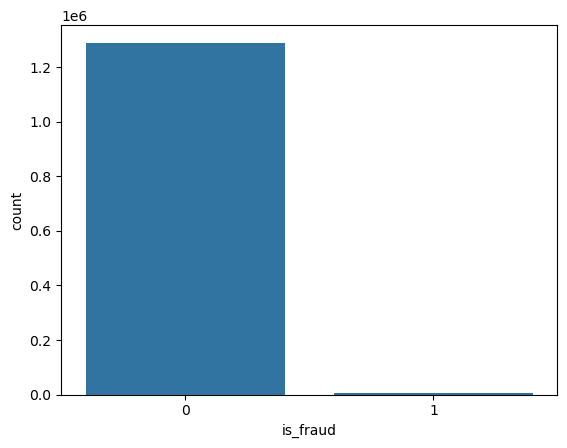

In [11]:
sns.countplot(x = 'is_fraud', data = df)

In [12]:
pd.Timedelta(days = 1)

Timedelta('1 days 00:00:00')

In [13]:
pd.Timedelta(days = 365)

Timedelta('365 days 00:00:00')

## 5. Feature Engineering
- `age_at_trans` — cardholder's age at the time of the transaction (from `dob`)
- `lat_dist` / `long_dist` — distance between the cardholder's home location and the merchant's location (a classic fraud signal — fraudulent transactions tend to happen far from the cardholder's usual location)
- `trans_month` — seasonality of the transaction

Groupby checks below confirm fraud is concentrated in specific cities/states/jobs rather than spread evenly, and that `category`, `gender` etc. are all usable categorical features.

In [14]:
df['age_at_trans'] = (df['trans_date'].dt.year) - (df['dob'].dt.year)

In [15]:
df['age_at_trans']

0          31
1          41
2          57
3          52
4          33
           ..
1296670    59
1296671    41
1296672    53
1296673    40
1296674    25
Name: age_at_trans, Length: 1296675, dtype: int32

In [16]:
df.head()

,trans_date_trans_time,category,amt,gender,city,state,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,trans_date,age_at_trans
0,2019-01-01 00:00:18,misc_net,4.97,F,Moravian Falls,NC,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,36.011293,-82.048315,0,2019-01-01,31
1,2019-01-01 00:00:44,grocery_pos,107.23,F,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,49.159047,-118.186462,0,2019-01-01,41
2,2019-01-01 00:00:51,entertainment,220.11,M,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,43.150704,-112.154481,0,2019-01-01,57
3,2019-01-01 00:01:16,gas_transport,45.00,M,Boulder,MT,46.2306,-112.1138,1939,Patent attorney,1967-01-12,47.034331,-112.561071,0,2019-01-01,52
4,2019-01-01 00:03:06,misc_pos,41.96,M,Doe Hill,VA,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,38.674999,-78.632459,0,2019-01-01,33


In [17]:
fraud_city = pd.DataFrame(df.groupby('city')['is_fraud'].sum())
fraud_city

,is_fraud
city,
Achille,13
Acworth,13
Adams,0
Afton,9
Akron,0
...,...
Woods Cross,0
Woodville,0
Yellowstone National Park,12


In [18]:
fraud_city = fraud_city[fraud_city['is_fraud']>0]
fraud_city.index

Index(['Achille', 'Acworth', 'Afton', 'Albany', 'Albuquerque', 'Alder',
       'Aledo', 'Alexandria', 'Allenhurst', 'Allentown',
       ...
       'Wilmington', 'Winfield', 'Winger', 'Winnsboro', 'Winslow', 'Winter',
       'Winthrop', 'Wittenberg', 'Yellowstone National Park', 'Zaleski'],
      dtype='object', name='city', length=702)

In [19]:
fraud_state = pd.DataFrame(df.groupby('state')['is_fraud'].sum())
fraud_state = fraud_state[fraud_state['is_fraud']>0]
fraud_state.index

Index(['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI',
       'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN',
       'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH',
       'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA',
       'WI', 'WV', 'WY'],
      dtype='object', name='state')

In [20]:
fraud_job = pd.DataFrame(df.groupby('job')['is_fraud'].sum())
fraud_job = fraud_job[fraud_job['is_fraud']>0]
fraud_job.index

Index(['Academic librarian', 'Accountant, chartered',
       'Accountant, chartered certified',
       'Accountant, chartered public finance', 'Accounting technician',
       'Acupuncturist', 'Administrator', 'Administrator, arts',
       'Administrator, charities/voluntary organisations',
       'Administrator, education',
       ...
       'Veterinary surgeon', 'Video editor', 'Volunteer coordinator',
       'Warden/ranger', 'Warehouse manager', 'Waste management officer',
       'Water quality scientist', 'Web designer', 'Wellsite geologist',
       'Writer'],
      dtype='object', name='job', length=443)

In [21]:
df['lat_dist'] = abs(round(df['merch_lat'] - df['lat'], 3))
df['long_dist'] = abs(round(df['merch_long'] - df['long'], 3))
df[['merch_lat', 'lat', 'lat_dist', 'merch_long', 'long', 'long_dist']].head()

,merch_lat,lat,lat_dist,merch_long,long,long_dist
0,36.011293,36.0788,0.068,-82.048315,-81.1781,0.870
1,49.159047,48.8878,0.271,-118.186462,-118.2105,0.024
2,43.150704,42.1808,0.970,-112.154481,-112.2620,0.108
3,47.034331,46.2306,0.804,-112.561071,-112.1138,0.447
4,38.674999,38.4207,0.254,-78.632459,-79.4629,0.830


In [22]:
df['trans_month'] = df['trans_date'].dt.month
df.head()

,trans_date_trans_time,category,amt,gender,city,state,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,trans_date,age_at_trans,lat_dist,long_dist,trans_month
0,2019-01-01 00:00:18,misc_net,4.97,F,Moravian Falls,NC,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,36.011293,-82.048315,0,2019-01-01,31,0.068,0.870,1
1,2019-01-01 00:00:44,grocery_pos,107.23,F,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,49.159047,-118.186462,0,2019-01-01,41,0.271,0.024,1
2,2019-01-01 00:00:51,entertainment,220.11,M,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,43.150704,-112.154481,0,2019-01-01,57,0.970,0.108,1
3,2019-01-01 00:01:16,gas_transport,45.00,M,Boulder,MT,46.2306,-112.1138,1939,Patent attorney,1967-01-12,47.034331,-112.561071,0,2019-01-01,52,0.804,0.447,1
4,2019-01-01 00:03:06,misc_pos,41.96,M,Doe Hill,VA,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,38.674999,-78.632459,0,2019-01-01,33,0.254,0.830,1


In [23]:
df['category'].value_counts()

category
gas_transport     131659
grocery_pos       123638
home              123115
shopping_pos      116672
kids_pets         113035
shopping_net       97543
entertainment      94014
food_dining        91461
personal_care      90758
health_fitness     85879
misc_pos           79655
misc_net           63287
grocery_net        45452
travel             40507
Name: count, dtype: int64

In [24]:
df['job'].value_counts()

job
Film/video editor             9779
Exhibition designer           9199
Naval architect               8684
Surveyor, land/geomatics      8680
Materials engineer            8270
                              ... 
Information officer              8
Veterinary surgeon               8
Ship broker                      7
Contracting civil engineer       7
Warehouse manager                7
Name: count, Length: 494, dtype: int64

In [25]:
df['gender'].value_counts()

gender
F    709863
M    586812
Name: count, dtype: int64

In [26]:
df['city'].value_counts()

city
Birmingham     5617
San Antonio    5130
Utica          5105
Phoenix        5075
Meridian       5060
               ... 
Vacaville         7
Claypool          7
Karns City        7
Bruce             7
Chattanooga       7
Name: count, Length: 894, dtype: int64

In [27]:
df['state'].value_counts()

state
TX    94876
NY    83501
PA    79847
CA    56360
OH    46480
MI    46154
IL    43252
FL    42671
AL    40989
MO    38403
MN    31714
AR    31127
NC    30266
WI    29368
VA    29250
SC    29190
KY    28475
IN    27580
IA    26985
OK    26671
MD    26193
GA    26063
WV    25691
NJ    24603
NE    24168
KS    22996
MS    21188
LA    20965
WY    19322
WA    18924
OR    18597
TN    17554
ME    16505
NM    16407
ND    14786
CO    13880
MA    12376
SD    12324
VT    11768
MT    11754
AZ    10770
UT    10699
NH     8278
CT     7702
NV     5607
ID     5545
DC     3613
HI     2559
AK     2120
RI      550
DE        9
Name: count, dtype: int64

In [28]:
categorical=df.select_dtypes(include="object")
for i in categorical:
    print("-"*100)
    print(i)
    print("-"*100)
    print(df[i].value_counts())
    print("="*100)

----------------------------------------------------------------------------------------------------
category
----------------------------------------------------------------------------------------------------
category
gas_transport     131659
grocery_pos       123638
home              123115
shopping_pos      116672
kids_pets         113035
shopping_net       97543
entertainment      94014
food_dining        91461
personal_care      90758
health_fitness     85879
misc_pos           79655
misc_net           63287
grocery_net        45452
travel             40507
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
gender
----------------------------------------------------------------------------------------------------
gender
F    709863
M    586812
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
city
--------------------------------

In [29]:
drop_cols = ['trans_date_trans_time', 'city','lat','job','dob','merch_lat','merch_long', 'trans_date']

df1 = df.drop(drop_cols, axis = 1)
df1.head()

,category,amt,gender,state,long,city_pop,is_fraud,age_at_trans,lat_dist,long_dist,trans_month
0,misc_net,4.97,F,NC,-81.1781,3495,0,31,0.068,0.870,1
1,grocery_pos,107.23,F,WA,-118.2105,149,0,41,0.271,0.024,1
2,entertainment,220.11,M,ID,-112.2620,4154,0,57,0.970,0.108,1
3,gas_transport,45.00,M,MT,-112.1138,1939,0,52,0.804,0.447,1
4,misc_pos,41.96,M,VA,-79.4629,99,0,33,0.254,0.830,1


## 6. Preprocessing — Encoding & Scaling
Remaining free-text/identifier columns are dropped, the remaining categorical columns (`category`, `gender`, `state`, `merchant` etc.) are label-encoded, and features are standardized before modeling.

In [30]:
from sklearn.preprocessing import LabelEncoder 
le=LabelEncoder()

In [31]:
category=df1.select_dtypes(include="object")

In [32]:
for i in category:
    df1[i]=le.fit_transform(df1[i])

In [33]:
df1.head()

,category,amt,gender,state,long,city_pop,is_fraud,age_at_trans,lat_dist,long_dist,trans_month
0,8,4.97,0,27,-81.1781,3495,0,31,0.068,0.870,1
1,4,107.23,0,47,-118.2105,149,0,41,0.271,0.024,1
2,0,220.11,1,13,-112.2620,4154,0,57,0.970,0.108,1
3,2,45.00,1,26,-112.1138,1939,0,52,0.804,0.447,1
4,9,41.96,1,45,-79.4629,99,0,33,0.254,0.830,1


### A note on outlier removal
A z-score check (`|z| < 3`) is shown below for reference, but is **not applied** to the modeling data. In fraud detection, statistical outliers are often exactly the signal we're trying to catch — removing them would strip out genuine fraud cases and make the imbalance problem worse, not better.

In [34]:
from scipy.stats import zscore

In [35]:
z=np.abs(zscore(df1))
df2=df1[(z<3).all(axis=1)]
print("shape of the DataFrame before outlier removal ",df1.shape)
print("shape of the DataFrame after outlier removal",df2.shape)
print("percentage of data loss is",(df1.shape[0]-df2.shape[0])/df1.shape[0]*100)

shape of the DataFrame before outlier removal  (1296675, 11)
shape of the DataFrame after outlier removal (1243100, 11)
percentage of data loss is 4.131721518499239


In [36]:
X=df1.drop(columns="is_fraud")
y=df1["is_fraud"]

In [37]:
from sklearn.preprocessing import StandardScaler 
sc=StandardScaler()

In [38]:
X=sc.fit_transform(X)

## 7. Model Building — Baseline Decision Tree
A plain `DecisionTreeClassifier` (no class balancing) is trained first, as the original baseline.

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.tree import DecisionTreeClassifier 

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.3, random_state=99)
print("X_train:", X_train.shape, "\ny_train:", y_train.shape)
print("X_test:", X_test.shape, "\ny_test:", y_test.shape)

X_train: (907672, 10) 
y_train: (907672,)
X_test: (389003, 10) 
y_test: (389003,)


In [41]:
dtc=DecisionTreeClassifier()
dtc.fit(X_train,y_train)
y_pred=dtc.predict(X_test)

In [42]:
from sklearn.metrics import classification_report

# Note: args corrected to (y_true, y_pred) — the original notebook had these swapped,
# which silently swaps the precision/recall values reported below.
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    386738
           1       0.65      0.67      0.66      2265

    accuracy                           1.00    389003
   macro avg       0.82      0.83      0.83    389003
weighted avg       1.00      1.00      1.00    389003



## 8. Handling Class Imbalance — Weighted Decision Tree
With fraud at well under 1% of transactions, a plain classifier can get ~99%+ "accuracy" while missing most fraud. Instead of oversampling (SMOTE is very costly to run at this scale — ~1.3M rows, ~1.29M of them the majority class), `class_weight="balanced"` is used, which re-weights the loss function during training so misclassifying the rare fraud class is penalized much more heavily, at no extra memory/runtime cost.

In [43]:
dtc_balanced = DecisionTreeClassifier(class_weight="balanced", random_state=99)
dtc_balanced.fit(X_train, y_train)
y_pred_balanced = dtc_balanced.predict(X_test)

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    386738
           1       0.69      0.65      0.67      2265

    accuracy                           1.00    389003
   macro avg       0.84      0.82      0.83    389003
weighted avg       1.00      1.00      1.00    389003



## 9. Model Evaluation & Comparison

In [44]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, precision_recall_curve, roc_curve
)

y_proba_original = dtc.predict_proba(X_test)[:, 1]
y_proba_balanced = dtc_balanced.predict_proba(X_test)[:, 1]

def fraud_metrics(name, y_true, y_pred, y_proba):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (fraud)": precision_score(y_true, y_pred, pos_label=1),
        "Recall (fraud)": recall_score(y_true, y_pred, pos_label=1),
        "F1 (fraud)": f1_score(y_true, y_pred, pos_label=1),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba),
    }

comparison_df = pd.DataFrame([
    fraud_metrics("Decision Tree - Original", y_test, y_pred, y_proba_original),
    fraud_metrics("Decision Tree - class_weight='balanced'", y_test, y_pred_balanced, y_proba_balanced),
])
comparison_df

,Model,Accuracy,Precision (fraud),Recall (fraud),F1 (fraud),ROC-AUC,PR-AUC
0,Decision Tree - Original,0.995961,0.648417,0.669316,0.658701,0.833595,0.435921
1,Decision Tree - class_weight='balanced',0.996267,0.691655,0.647682,0.668947,0.822996,0.450024


### Why accuracy is misleading here

In [45]:
fraud_rate = y.mean()
majority_class_accuracy = 1 - fraud_rate
print(f"Fraud rate in the data: {fraud_rate:.4%}")
print(f"A model that predicts 'not fraud' for every single transaction would score "
      f"{majority_class_accuracy:.4%} accuracy while catching ZERO fraud (0% recall).")
print("This is why precision, recall, F1 and ROC-AUC/PR-AUC on the fraud class are reported instead of accuracy.")

Fraud rate in the data: 0.5789%
A model that predicts 'not fraud' for every single transaction would score 99.4211% accuracy while catching ZERO fraud (0% recall).
This is why precision, recall, F1 and ROC-AUC/PR-AUC on the fraud class are reported instead of accuracy.


### Confusion Matrices

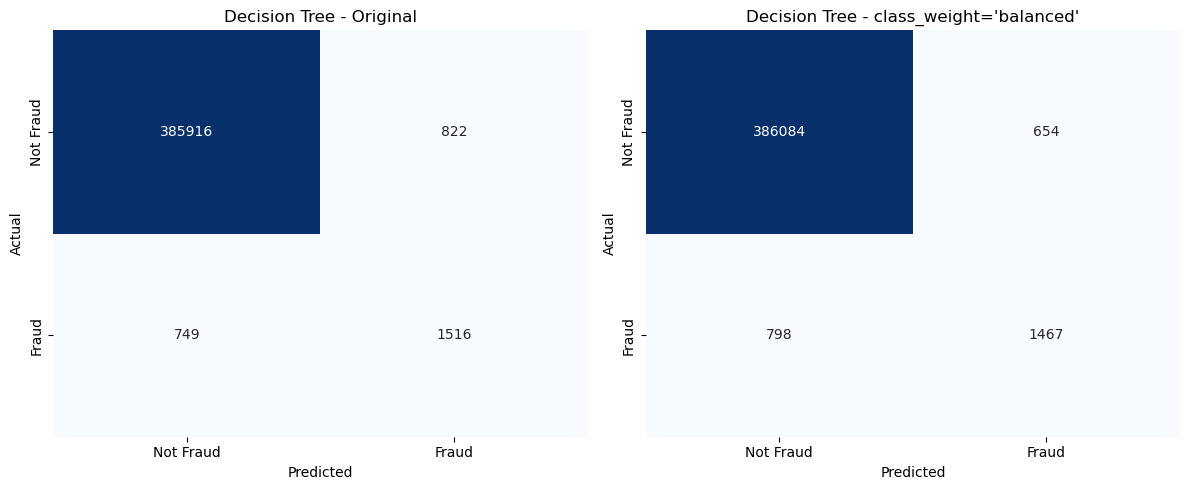

In [46]:
import os
os.makedirs("../images", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, preds) in zip(axes, [("Original", y_pred), ("class_weight='balanced'", y_pred_balanced)]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Not Fraud", "Fraud"], yticklabels=["Not Fraud", "Fraud"], ax=ax)
    ax.set_title(f"Decision Tree - {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("../images/confusion_matrices.png", dpi=150)
plt.show()

### Precision-Recall Curve
The PR curve (rather than ROC) is the more informative view for a rare positive class like fraud.

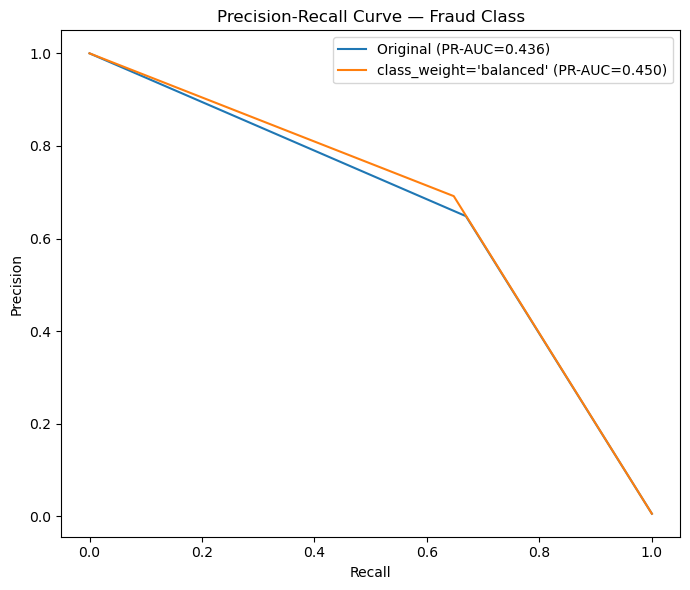

In [47]:
precision_o, recall_o, _ = precision_recall_curve(y_test, y_proba_original)
precision_b, recall_b, _ = precision_recall_curve(y_test, y_proba_balanced)

plt.figure(figsize=(7, 6))
plt.plot(recall_o, precision_o, label=f"Original (PR-AUC={average_precision_score(y_test, y_proba_original):.3f})")
plt.plot(recall_b, precision_b, label=f"class_weight='balanced' (PR-AUC={average_precision_score(y_test, y_proba_balanced):.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Fraud Class")
plt.legend()
plt.tight_layout()
plt.savefig("../images/precision_recall_curve.png", dpi=150)
plt.show()

### Fraud Class Distribution

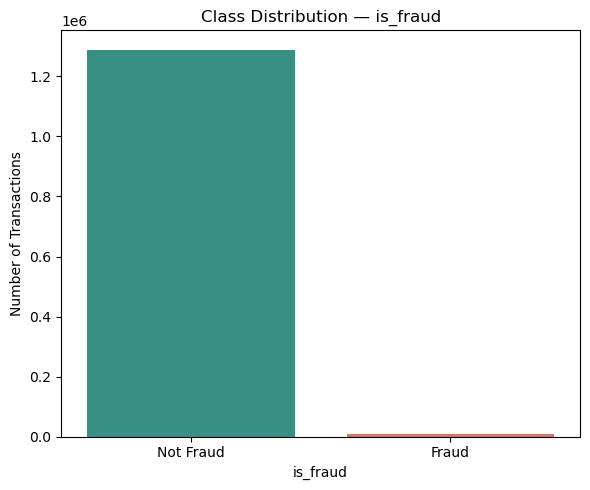

In [48]:
plt.figure(figsize=(6, 5))
sns.countplot(x="is_fraud", data=df1, palette=["#2a9d8f", "#e76f51"])
plt.xticks([0, 1], ["Not Fraud", "Fraud"])
plt.ylabel("Number of Transactions")
plt.title("Class Distribution — is_fraud")
plt.tight_layout()
plt.savefig("../images/class_distribution.png", dpi=150)
plt.show()

## 10. Conclusion

**Dataset:** 1,296,675 transactions, only **7,506 (0.58%) fraudulent** — split 70/30 into train (907,672) and test (389,003) sets.

**Results (test set):**

| Model | Accuracy | Precision (fraud) | Recall (fraud) | F1 (fraud) | ROC-AUC | PR-AUC |
|---|---|---|---|---|---|---|
| Decision Tree — Original | 0.9960 | 0.648 | 0.669 | 0.659 | **0.834** | 0.436 |
| Decision Tree — `class_weight='balanced'` | 0.9963 | **0.692** | 0.648 | **0.669** | 0.823 | **0.450** |

Confusion matrices (fraud = positive class, 2,265 actual frauds in the test set):
- **Original:** 1,516 frauds caught, 749 missed, 822 false alarms
- **`class_weight='balanced'`:** 1,467 frauds caught, 798 missed, **654 false alarms (-20%)**

**Key findings**
- Fraud is only 0.58% of transactions, so a model that predicts "not fraud" every time would score **99.42% accuracy while catching zero fraud** — this is exactly why accuracy is reported here only to show how misleading it is, and every other metric focuses on the fraud class specifically.
- `class_weight='balanced'` is a genuine **precision/recall trade-off, not a one-sided win**: it cuts false alarms by ~20% (822 → 654) and improves F1 and PR-AUC, but it also catches slightly less fraud (1,467 vs 1,516 caught) and has marginally lower ROC-AUC. Which model is "better" depends on the business cost of a false alarm vs. a missed fraud.
- On balance, **PR-AUC (the more informative metric for this level of imbalance) and F1 both favour the `class_weight='balanced'` model**, so it is the one taken forward here — but neither model is good enough to deploy as-is (see limitations).

**Limitations**
- A single Decision Tree is a relatively weak, high-variance model. Ensemble methods (Random Forest, XGBoost/LightGBM with `scale_pos_weight`) are known to perform substantially better on this exact public dataset.
- SMOTE oversampling was **not used** at this scale (1.3M rows, 99.4% majority class) — generating synthetic samples up to majority size would be very memory/time-expensive. `class_weight='balanced'` was used instead as a lightweight, no-resampling alternative; a subsampled + SMOTE approach is worth revisiting if more compute is available.
- Engineered features stop at distance (`lat_dist`/`long_dist`), age and month — real fraud systems typically add **velocity features** (e.g. transactions per card in the last hour/day), which are known to be strong signals and weren't built here.
- The train/test split is a random 70/30 split of the same time period, not a time-based split — in production, fraud patterns drift over time, so a time-based validation would better reflect real deployment.

**Next steps**
- Try ensemble models (Random Forest / XGBoost) with `class_weight`/`scale_pos_weight`.
- Engineer velocity-based features (transactions per card per hour/day).
- Use a time-based train/test split instead of a random one.
- Tune the classification threshold (instead of the default 0.5) using the precision-recall curve above, to match the real business cost of a false positive vs. a missed fraud.

**Recommendation:** the **Decision Tree with `class_weight='balanced'`** is the model taken forward from this notebook (better F1 and PR-AUC, ~20% fewer false alarms), with the understanding that an ensemble model and better features would be the next real improvement, not further tuning of a single tree.